In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:


df = pd.read_csv("C:\Personal\coding\S1\hadi_skripsi\Results\Tuning\cnn_results.csv")

# Ambil index accuracy tertinggi untuk tiap feature
idx = df.groupby("feature")["test_acc"].idxmax()

# Ambil baris terbaik tiap feature
best_per_feature = df.loc[idx]

# Urutkan dari accuracy terbesar
best_per_feature = best_per_feature.sort_values(
    "test_acc",
    ascending=False
)

print(best_per_feature)

      experiment_id        feature  k1   k2  dropout1  dropout2  batch_size  \
91               92           MFCC  32  256       0.3       0.3          16   
1072           1073      MFCC+GFCC  32  256       0.3       0.4          16   
361             362           GFCC  32  128       0.2       0.3          16   
2143           2144  MFCC+GFCC+LPC  64  256       0.3       0.3          16   
1684           1685       GFCC+LPC  32  128       0.3       0.4          16   
1453           1454       MFCC+LPC  64  128       0.2       0.4          32   
838             839            LPC  64  256       0.2       0.4          16   

         lr   test_acc  precision    recall  f1_score  final_train_loss  \
91    0.001  75.322165   0.741549  0.753222  0.738558          0.519194   
1072  0.001  75.128866   0.739470  0.751289  0.733180          0.509188   
361   0.001  74.033505   0.728843  0.740335  0.711110          0.520898   
2143  0.001  74.033505   0.732875  0.740335  0.735386          0.51

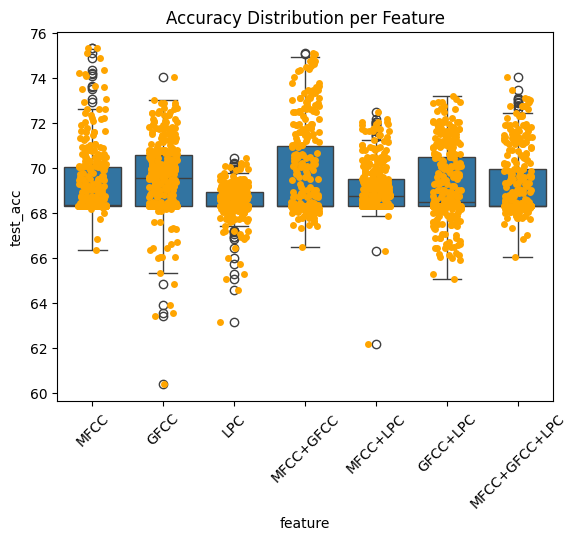

In [3]:
sns.boxplot(data=df, x="feature", y="test_acc")
sns.stripplot(data=df, x="feature", y="test_acc", color="orange", jitter=0.2, size=5)
plt.title("Accuracy Distribution per Feature")
plt.xticks(rotation=45)
plt.show()

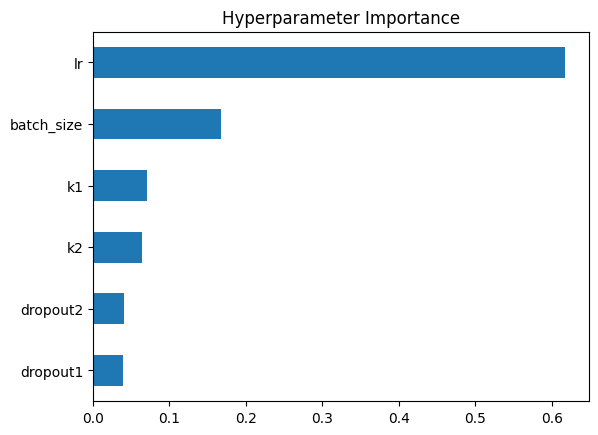

In [4]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

X = df[["k1","k2","dropout1","dropout2","batch_size","lr"]]
y = df["test_acc"]

model = RandomForestRegressor()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Hyperparameter Importance")
plt.show()

In [5]:
ranking = df.groupby("feature")["test_acc"].max().sort_values(ascending=False)
print("Ranking Fitur berdasarkan Akurasi Tertinggi:")
print(ranking)

Ranking Fitur berdasarkan Akurasi Tertinggi:
feature
MFCC             75.322165
MFCC+GFCC        75.128866
GFCC             74.033505
MFCC+GFCC+LPC    74.033505
GFCC+LPC         73.195876
MFCC+LPC         72.487113
LPC              70.425258
Name: test_acc, dtype: float64


In [6]:
ranking = df.groupby("feature")["test_acc"].mean().sort_values(ascending=False)
print("Ranking Fitur berdasarkan Akurasi Rata-rata:")
print(ranking)

Ranking Fitur berdasarkan Akurasi Rata-rata:
feature
MFCC+GFCC        69.633567
GFCC             69.554617
MFCC             69.249952
MFCC+GFCC+LPC    69.223304
GFCC+LPC         69.177366
MFCC+LPC         69.092847
LPC              68.491870
Name: test_acc, dtype: float64


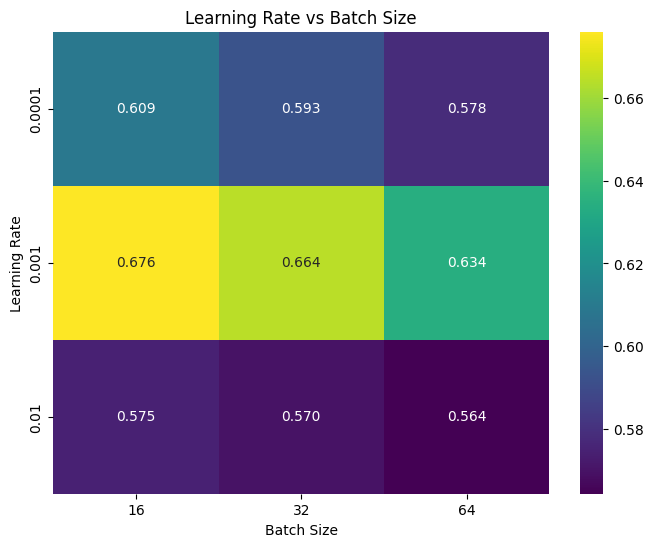

In [7]:
pivot = df.pivot_table(
    values="f1_score",
    index="lr",
    columns="batch_size",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("Learning Rate vs Batch Size")
plt.ylabel("Learning Rate")
plt.xlabel("Batch Size")

plt.show()

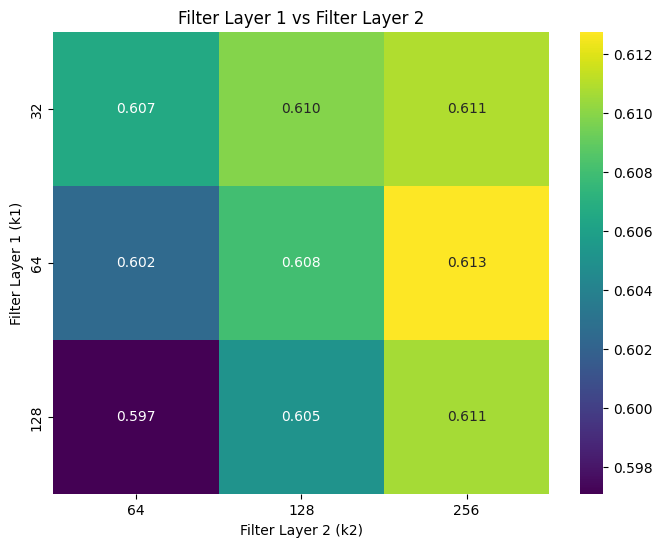

In [8]:
pivot = df.pivot_table(
    values="f1_score",
    index="k1",
    columns="k2",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("Filter Layer 1 vs Filter Layer 2")
plt.ylabel("Filter Layer 1 (k1)")
plt.xlabel("Filter Layer 2 (k2)")

plt.show()

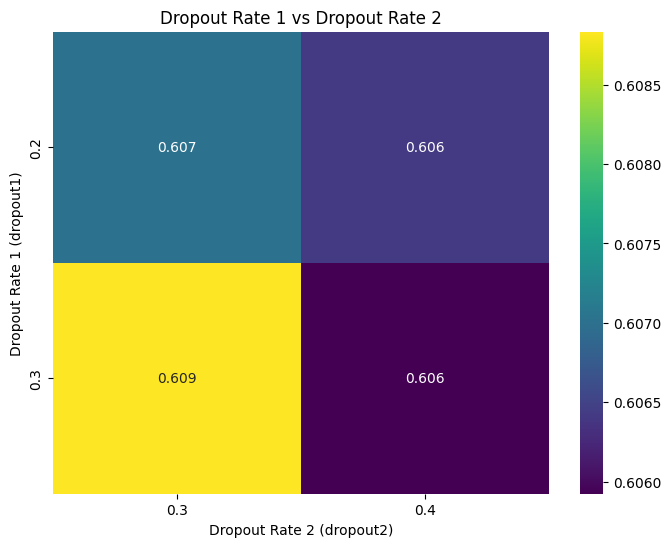

In [9]:
pivot = df.pivot_table(
    values="f1_score",
    index="dropout1",
    columns="dropout2",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("Dropout Rate 1 vs Dropout Rate 2")
plt.ylabel("Dropout Rate 1 (dropout1)")
plt.xlabel("Dropout Rate 2 (dropout2)")

plt.show()

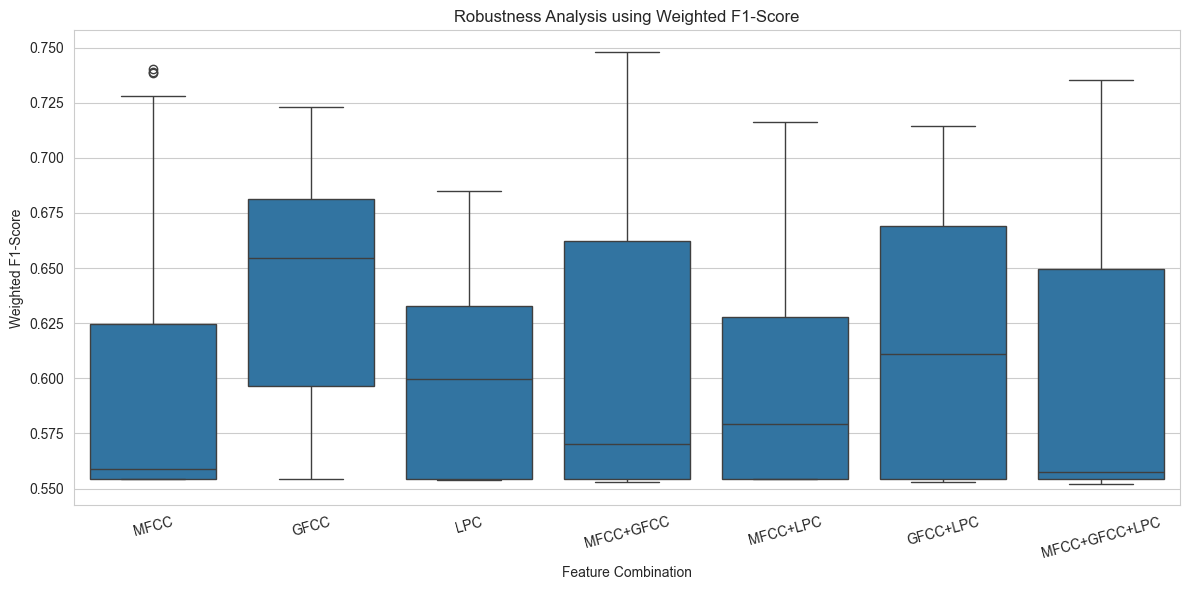

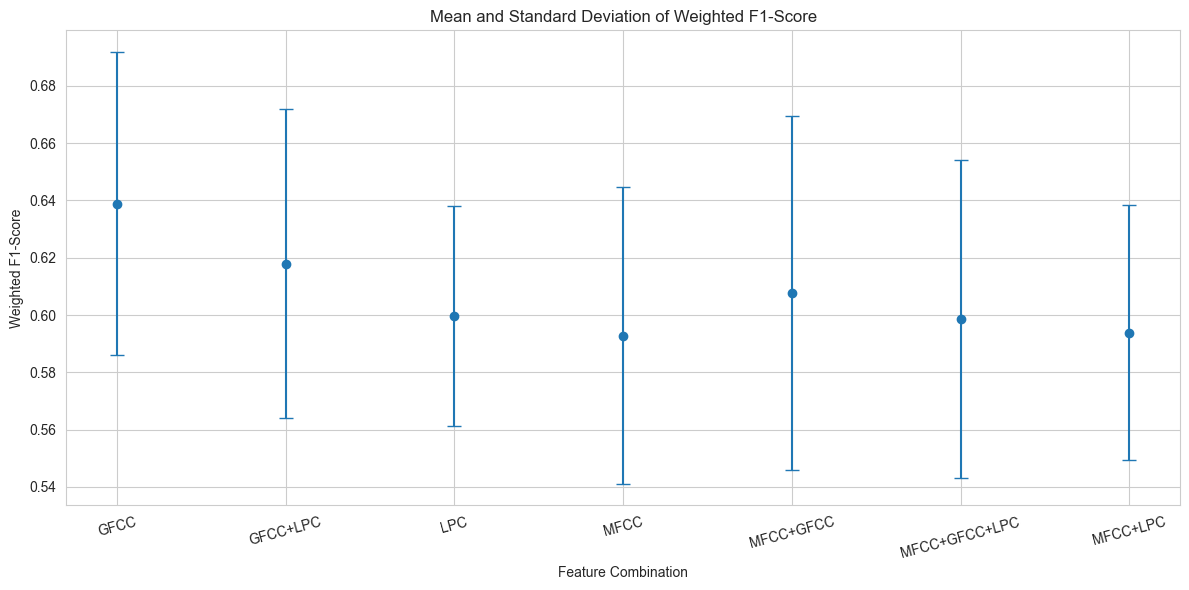

In [10]:
sns.set_style("whitegrid")

# =====================================================
# 1. BOXPLOT ROBUSTNESS ANALYSIS
# =====================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="feature",
    y="f1_score"
)

plt.title("Robustness Analysis using Weighted F1-Score")
plt.xlabel("Feature Combination")
plt.ylabel("Weighted F1-Score")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# =====================================================
# 2. ERROR BAR PLOT (MEAN ± STD)
# =====================================================

# Calculate mean and std
summary = (
    df.groupby("feature")["f1_score"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.errorbar(
    x=summary["feature"],
    y=summary["mean"],
    yerr=summary["std"],
    fmt='o',
    capsize=5
)

plt.title("Mean and Standard Deviation of Weighted F1-Score")
plt.xlabel("Feature Combination")
plt.ylabel("Weighted F1-Score")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

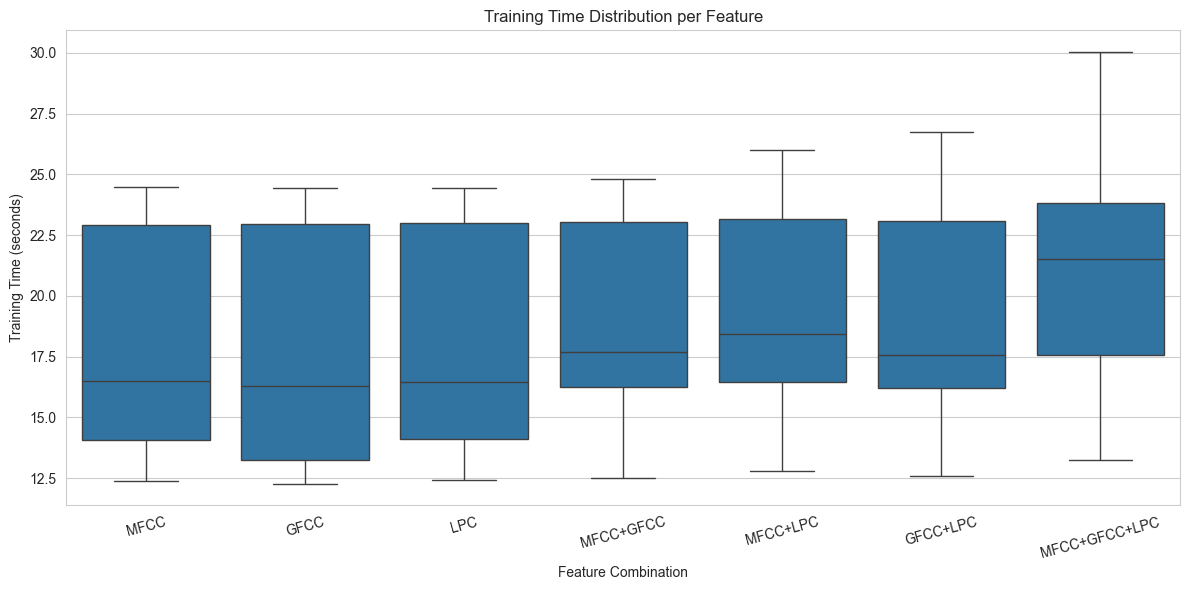

In [11]:
rder = (
    df.groupby("feature")["training_time_sec"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# =====================================================
# BOXPLOT TRAINING TIME
# =====================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="feature",
    y="training_time_sec",
)

plt.title("Training Time Distribution per Feature")
plt.xlabel("Feature Combination")
plt.ylabel("Training Time (seconds)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

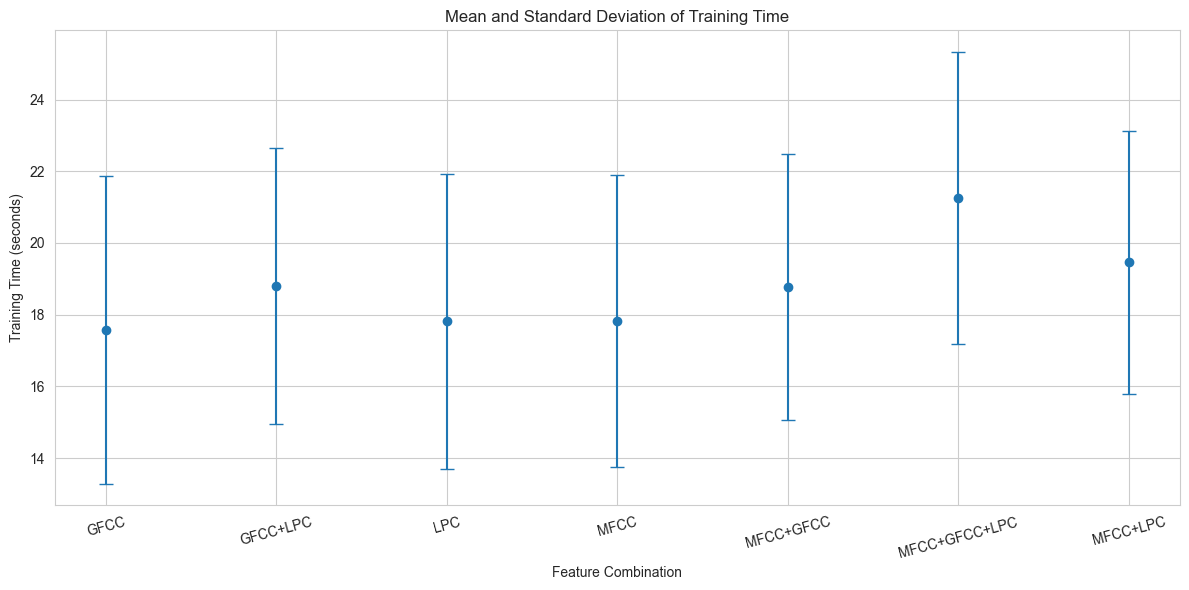

In [12]:
summary = (
    df.groupby("feature")["training_time_sec"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.errorbar(
    x=summary["feature"],
    y=summary["mean"],
    yerr=summary["std"],
    fmt='o',
    capsize=5
)

plt.title("Mean and Standard Deviation of Training Time")
plt.xlabel("Feature Combination")
plt.ylabel("Training Time (seconds)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

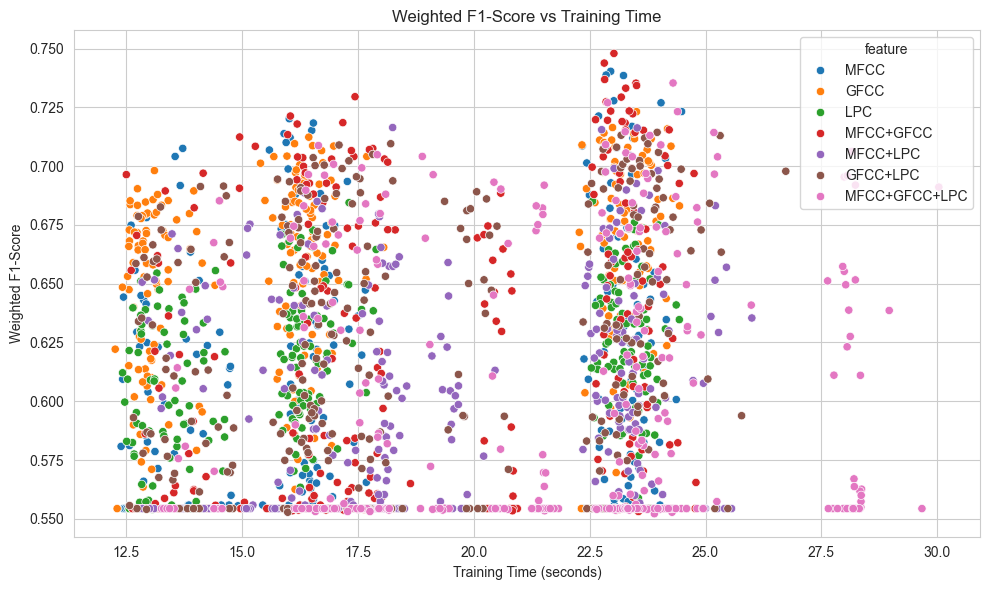

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="training_time_sec",
    y="f1_score",
    hue="feature"
)

plt.title("Weighted F1-Score vs Training Time")
plt.xlabel("Training Time (seconds)")
plt.ylabel("Weighted F1-Score")

plt.tight_layout()
plt.show()

In [14]:

robustness_table = (
    df.groupby("feature")
    .agg(
        mean_acc=("test_acc", "mean"),
        mean_f1=("f1_score", "mean"),
        std_f1=("f1_score", "std"),
        mean_training_time=("training_time_sec", "mean")
    )
    .reset_index()
    .sort_values(
        by="mean_f1",
        ascending=False
    )
)

print(robustness_table)


         feature   mean_acc   mean_f1    std_f1  mean_training_time
0           GFCC  69.554617  0.638872  0.052944           17.569275
1       GFCC+LPC  69.177366  0.617936  0.053928           18.803321
4      MFCC+GFCC  69.633567  0.607615  0.061843           18.782958
2            LPC  68.491870  0.599630  0.038298           17.816679
5  MFCC+GFCC+LPC  69.223304  0.598601  0.055671           21.261191
6       MFCC+LPC  69.092847  0.593826  0.044541           19.459094
3           MFCC  69.249952  0.592836  0.051787           17.825426


In [15]:

top_df = df.sort_values(
    "f1_score",
    ascending=False
).head(50)


summary = {
    "learning_rate": top_df["lr"].mode()[0],
    "batch_size": top_df["batch_size"].mode()[0],
    "k1": top_df["k1"].mode()[0],
    "k2": top_df["k2"].mode()[0],
    "dropout1": top_df["dropout1"].mode()[0],
    "dropout2": top_df["dropout2"].mode()[0],
}

freq_table = pd.DataFrame({
    "Hyperparameter": summary.keys(),
    "Most Frequent Value": summary.values()
})

print(freq_table)

  Hyperparameter  Most Frequent Value
0  learning_rate                0.001
1     batch_size               16.000
2             k1               32.000
3             k2              256.000
4       dropout1                0.200
5       dropout2                0.300


In [16]:
tradeoff_table = (
    df.groupby("feature")
    .agg(
        mean_f1=("f1_score", "mean"),
        std_f1=("f1_score", "std"),
        mean_training_time=("training_time_sec", "mean"),
        mean_num_params=("num_params", "mean")
    )
    .reset_index()
    .sort_values(
        by="mean_f1",
        ascending=False
    )
)

print(tradeoff_table)

         feature   mean_f1    std_f1  mean_training_time  mean_num_params
0           GFCC  0.638872  0.052944           17.569275    101548.666667
1       GFCC+LPC  0.617936  0.053928           18.803321    101548.666667
4      MFCC+GFCC  0.607615  0.061843           18.782958    101548.666667
2            LPC  0.599630  0.038298           17.816679    101548.666667
5  MFCC+GFCC+LPC  0.598601  0.055671           21.261191    101548.666667
6       MFCC+LPC  0.593826  0.044541           19.459094    101548.666667
3           MFCC  0.592836  0.051787           17.825426    101548.666667


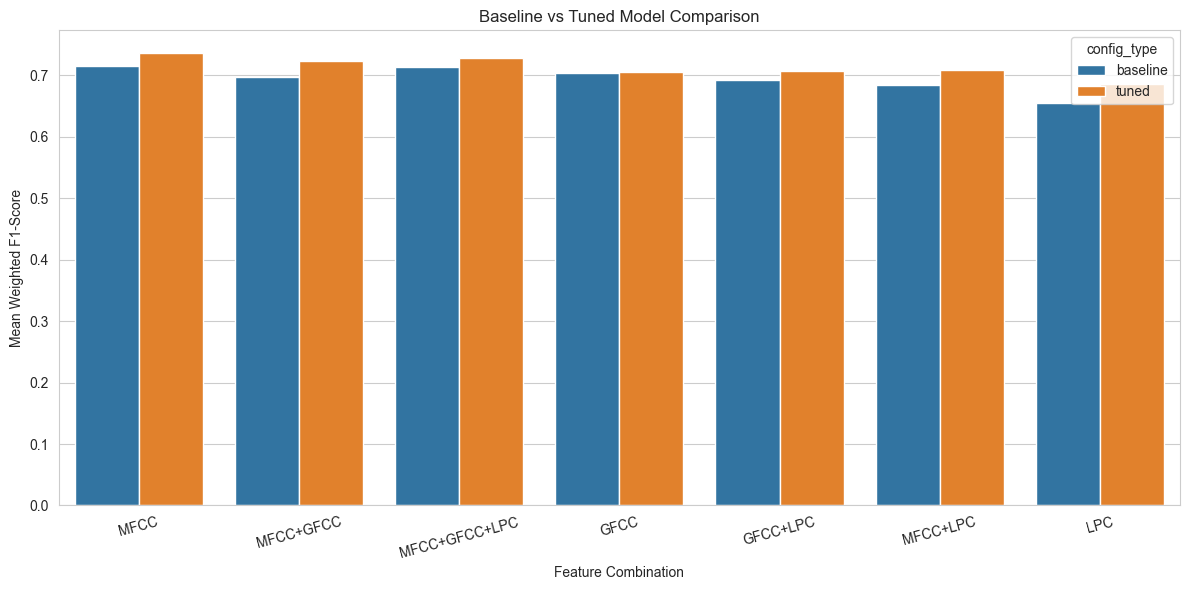

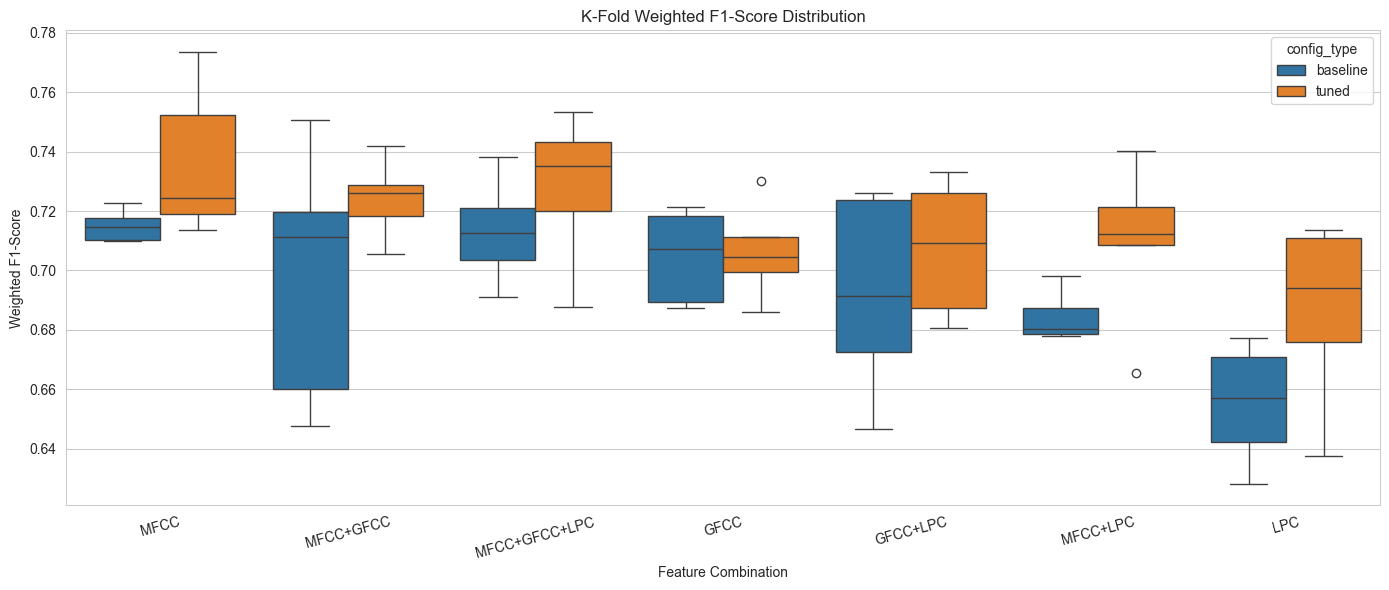

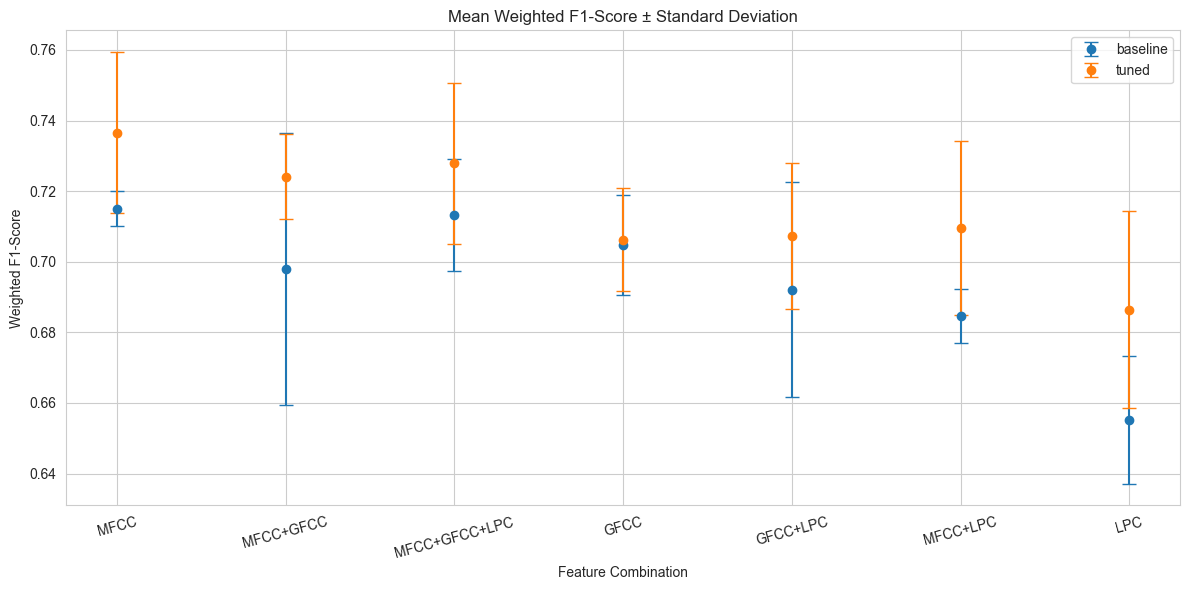

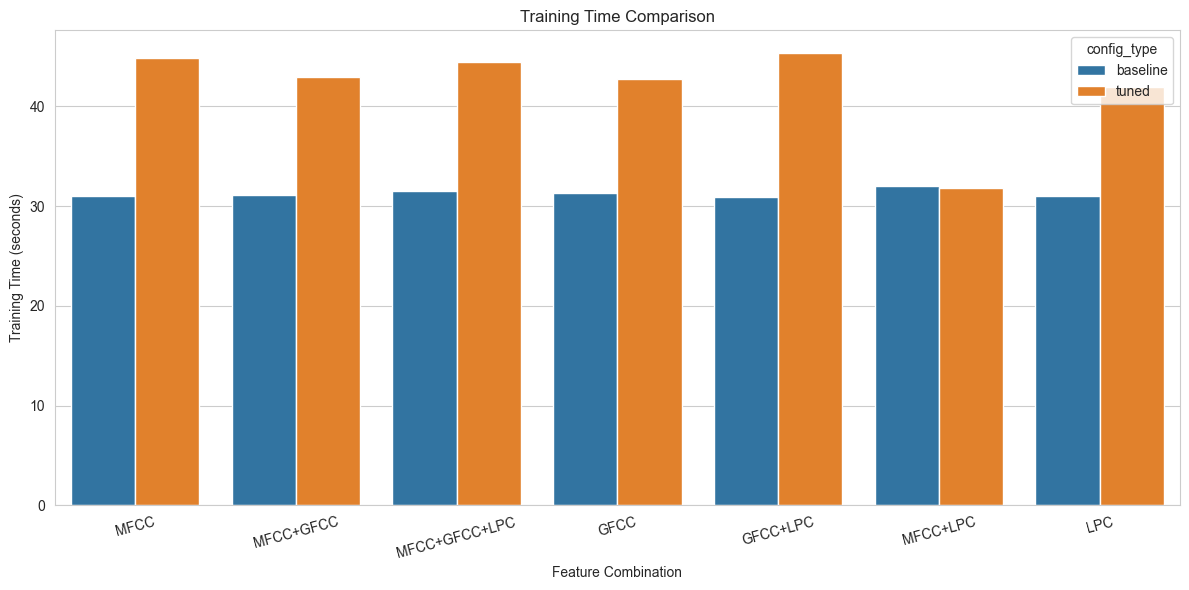

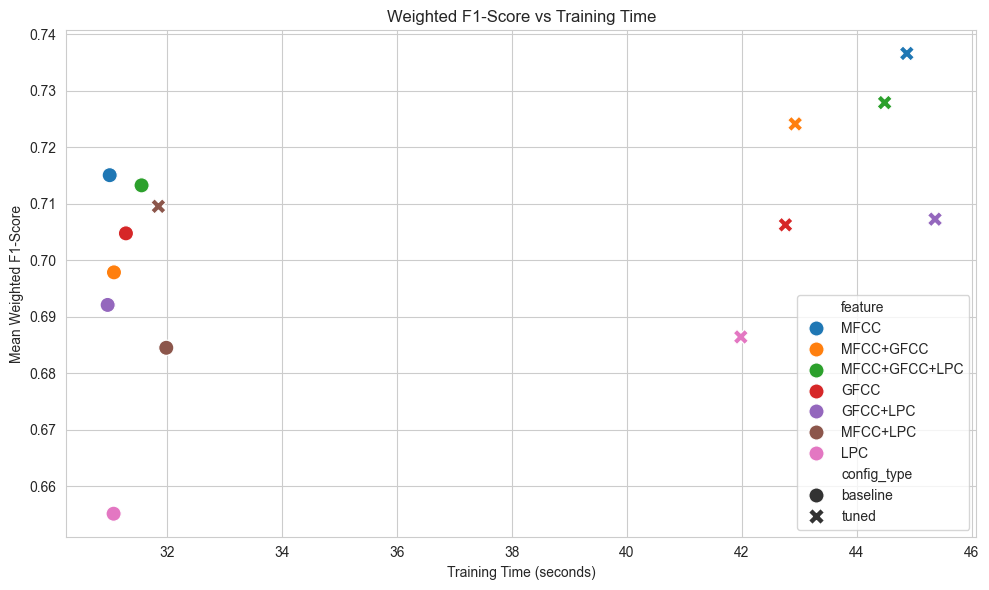

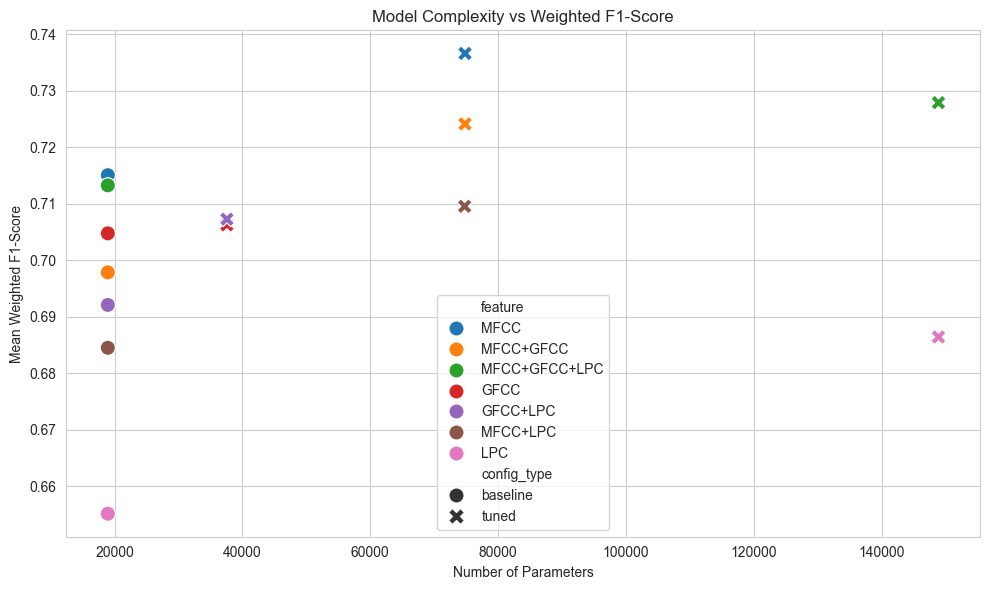

FEATURE : MFCC


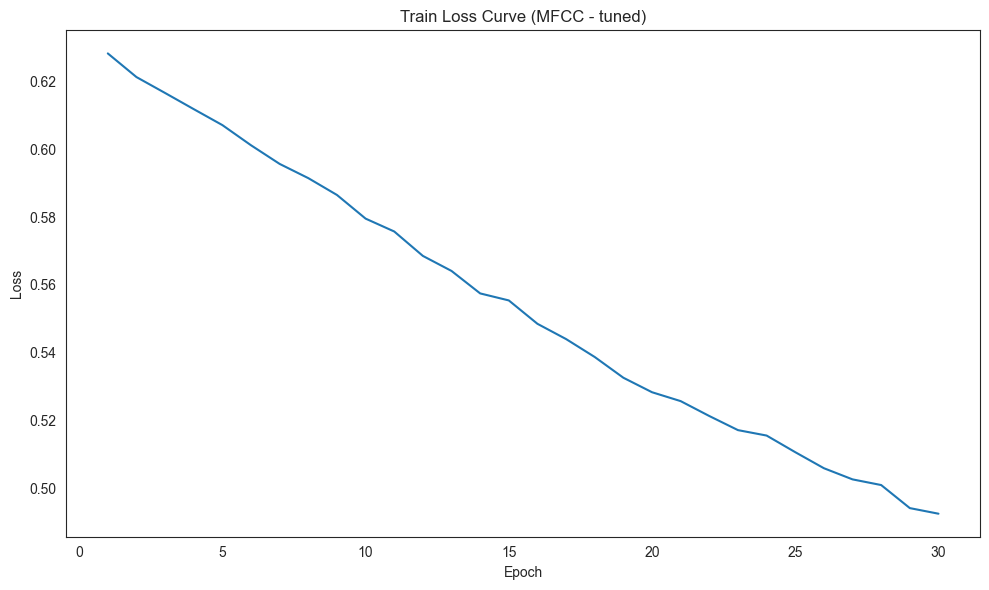

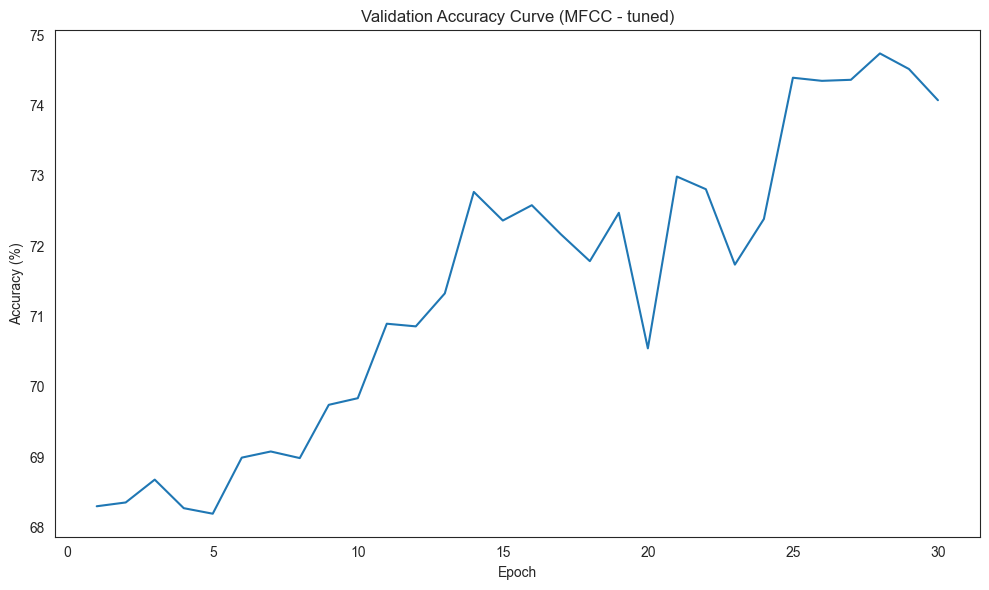

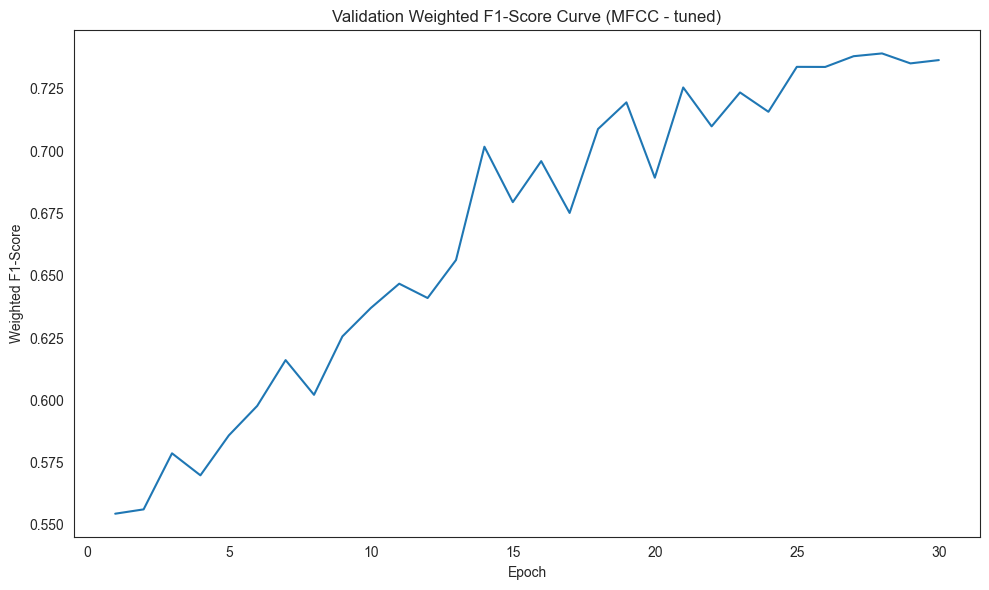

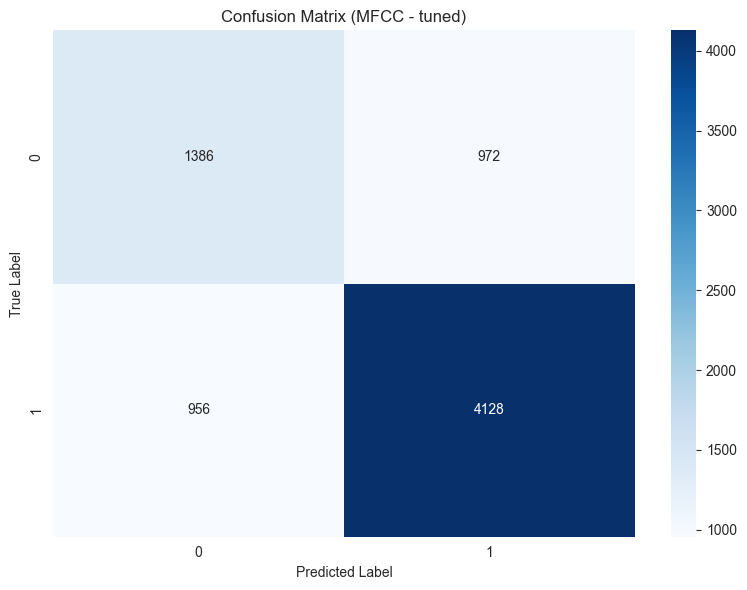


Mean Accuracy:
0.7407773698578487

Mean Classification Report:
   precision    recall  f1-score
0   0.616354  0.588040  0.582492
1   0.814706  0.811635  0.808085


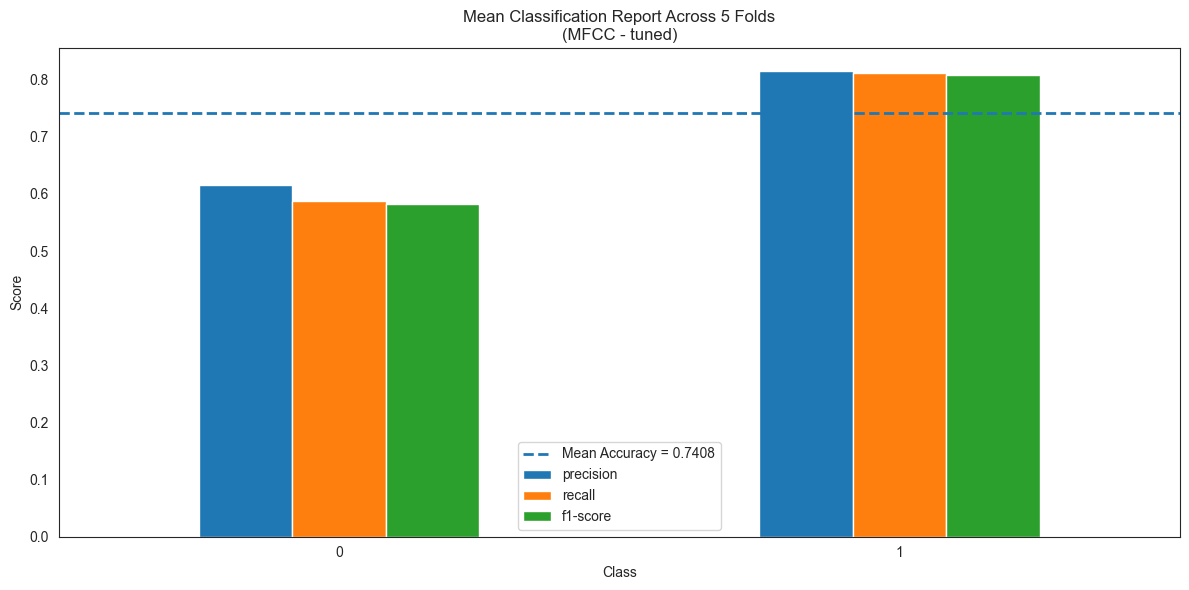

FEATURE : MFCC+GFCC


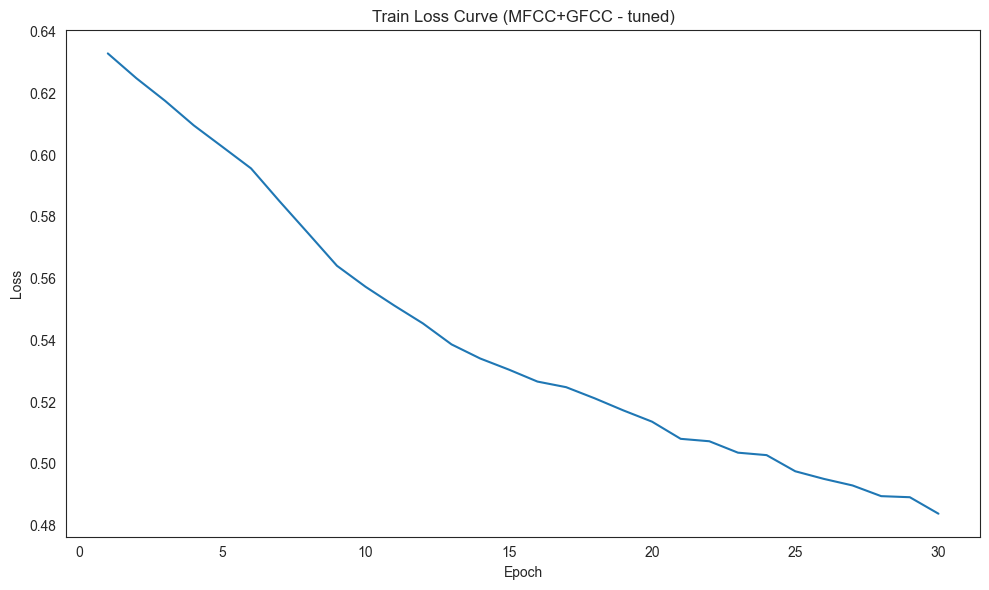

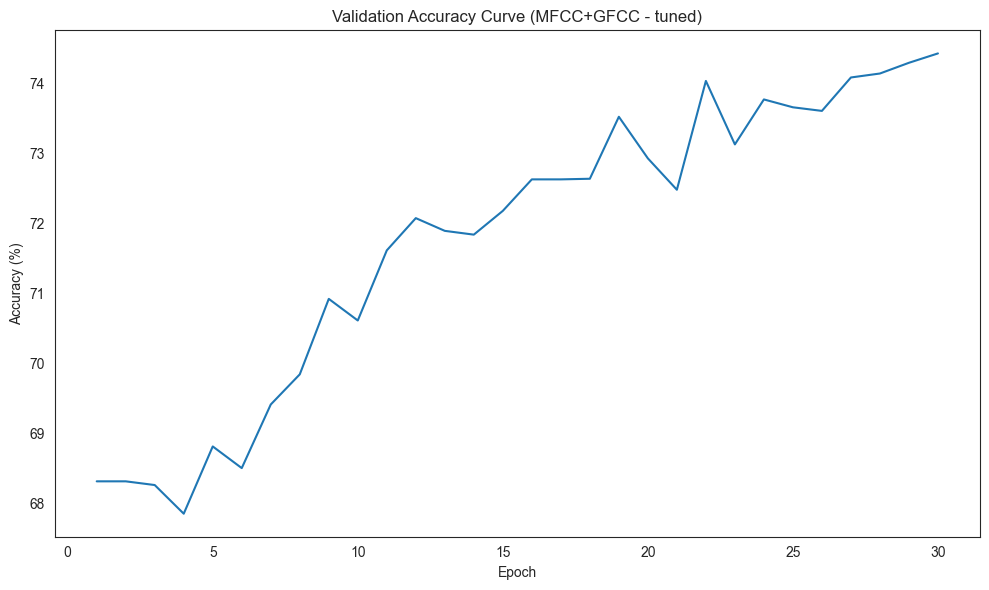

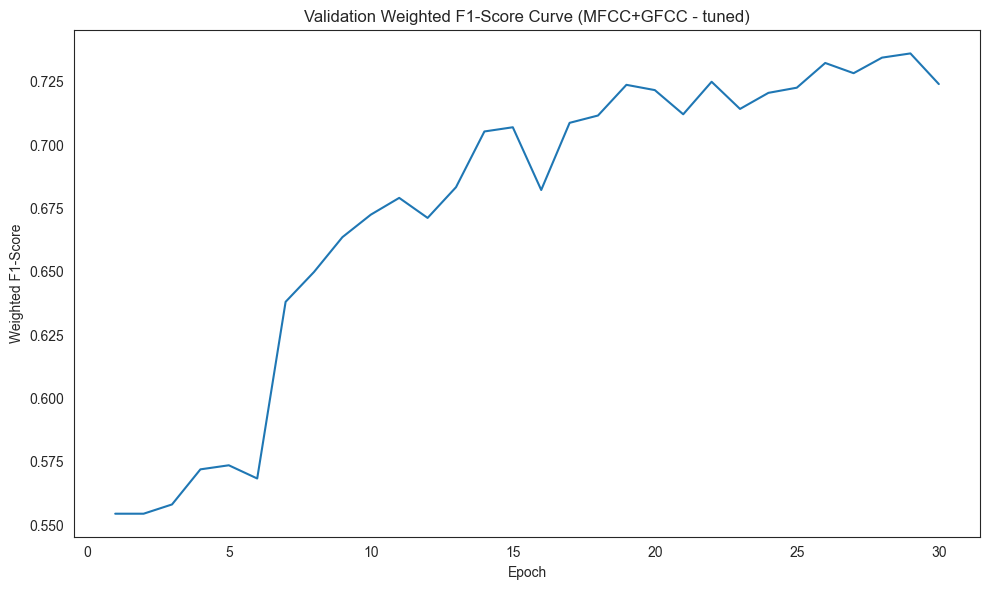

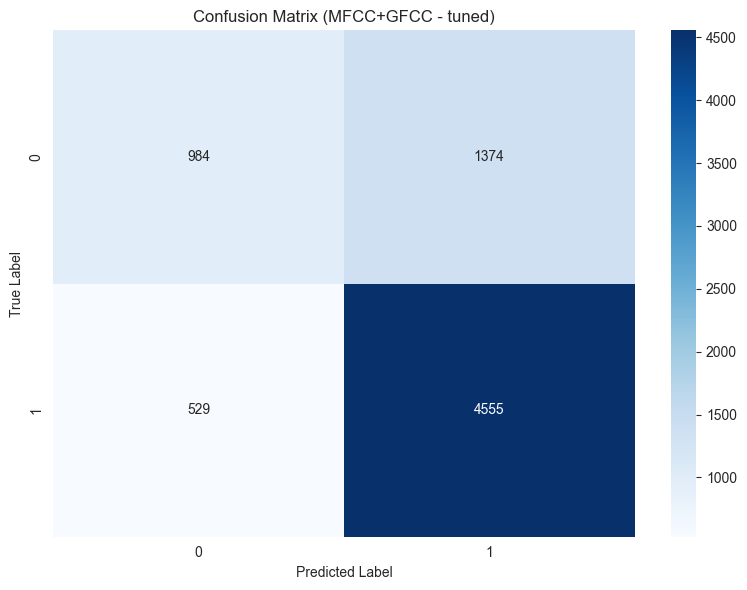


Mean Accuracy:
0.7443021628041265

Mean Classification Report:
   precision    recall  f1-score
0   0.663331  0.415558  0.502361
1   0.769399  0.896763  0.826981


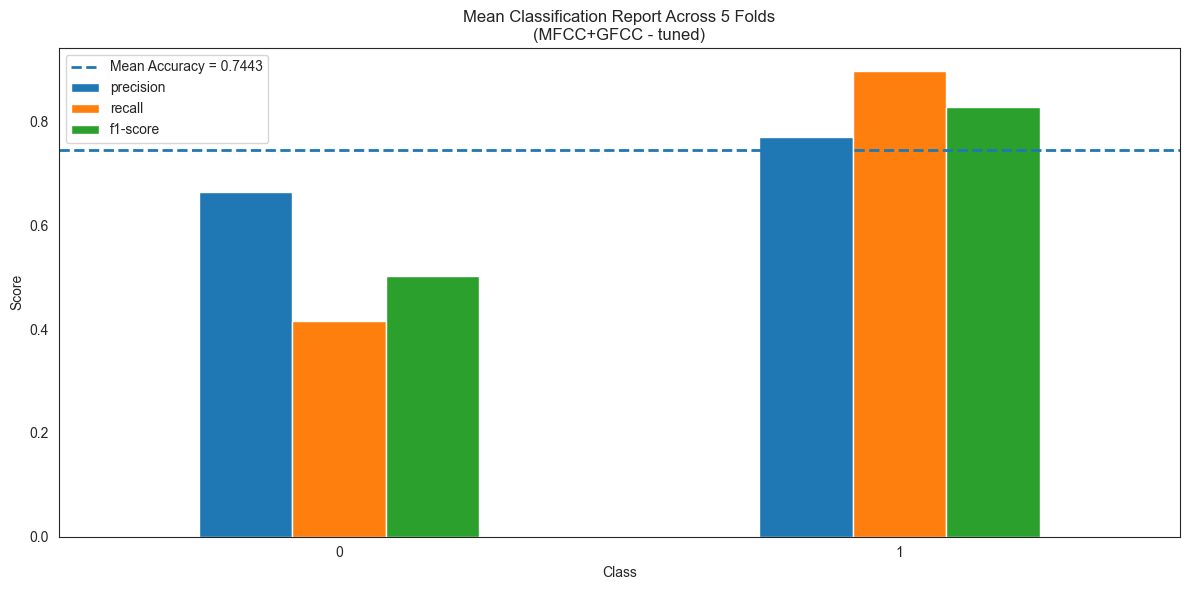

In [19]:
# =====================================================
# VISUALISASI FINAL TRAINING DAN EVALUASI MODEL
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

sns.set_style("whitegrid")

# =====================================================
# LOAD DATA
# =====================================================

RESULT_PATH = r"C:\Personal\coding\S1\hadi_skripsi\Results\Final_KFold\final_kfold_results.csv"

FEATURES = [
    "MFCC",
    "GFCC",
    "LPC",
    "MFCC+GFCC",
    "MFCC+LPC",
    "GFCC+LPC",
    "MFCC+GFCC+LPC"
]

# =====================================================
# HANYA FEATURE TERPILIH YANG DITUNED
# =====================================================

SELECTED_FEATURES = [
    "MFCC",
    "MFCC+GFCC",
]

results_df = pd.read_csv(RESULT_PATH)

# =====================================================
# 1. BASELINE VS TUNED COMPARISON
# MASIH MENGGUNAKAN SEMUA FITUR
# =====================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="feature",
    y="mean_f1",
    hue="config_type"
)

plt.title("Baseline vs Tuned Model Comparison")
plt.xlabel("Feature Combination")
plt.ylabel("Mean Weighted F1-Score")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# =====================================================
# 2. K-FOLD STABILITY VISUALIZATION
# MASIH MENGGUNAKAN SEMUA FITUR
# =====================================================

fold_columns = [
    col for col in results_df.columns
    if "fold_" in col and "_f1" in col
]

melted_fold = results_df.melt(
    id_vars=["feature", "config_type"],
    value_vars=fold_columns,
    var_name="fold",
    value_name="f1_score"
)

plt.figure(figsize=(14,6))

sns.boxplot(
    data=melted_fold,
    x="feature",
    y="f1_score",
    hue="config_type"
)

plt.title("K-Fold Weighted F1-Score Distribution")
plt.xlabel("Feature Combination")
plt.ylabel("Weighted F1-Score")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# =====================================================
# 3. MEAN F1 WITH ERROR BAR
# MASIH MENGGUNAKAN SEMUA FITUR
# =====================================================

plt.figure(figsize=(12,6))

for config in results_df["config_type"].unique():

    subset = results_df[
        results_df["config_type"] == config
    ]

    plt.errorbar(
        x=subset["feature"],
        y=subset["mean_f1"],
        yerr=subset["std_f1"],
        fmt='o',
        capsize=5,
        label=config
    )

plt.title("Mean Weighted F1-Score ± Standard Deviation")
plt.xlabel("Feature Combination")
plt.ylabel("Weighted F1-Score")

plt.legend()
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# =====================================================
# 4. TRAINING TIME COMPARISON
# MASIH MENGGUNAKAN SEMUA FITUR
# =====================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="feature",
    y="training_time_sec",
    hue="config_type"
)

plt.title("Training Time Comparison")
plt.xlabel("Feature Combination")
plt.ylabel("Training Time (seconds)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# =====================================================
# 5. PERFORMANCE VS COMPUTATIONAL COST
# MASIH MENGGUNAKAN SEMUA FITUR
# =====================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=results_df,
    x="training_time_sec",
    y="mean_f1",
    hue="feature",
    style="config_type",
    s=120
)

plt.title("Weighted F1-Score vs Training Time")
plt.xlabel("Training Time (seconds)")
plt.ylabel("Mean Weighted F1-Score")

plt.tight_layout()
plt.show()

# =====================================================
# 6. MODEL COMPLEXITY ANALYSIS
# MASIH MENGGUNAKAN SEMUA FITUR
# =====================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=results_df,
    x="num_params",
    y="mean_f1",
    hue="feature",
    style="config_type",
    s=120
)

plt.title("Model Complexity vs Weighted F1-Score")
plt.xlabel("Number of Parameters")
plt.ylabel("Mean Weighted F1-Score")

plt.tight_layout()
plt.show()

# =====================================================
# 7. LEARNING CURVE, CM, DAN CLASSIFICATION REPORT
# HANYA UNTUK SELECTED FEATURES YANG TUNED
# =====================================================

sns.set_style("white")

for feature in SELECTED_FEATURES:

    print("=" * 60)
    print(f"FEATURE : {feature}")

    config = "tuned"

    # =====================================================
    # LOAD LEARNING CURVE
    # =====================================================

    curve_path = (
        r"C:\Personal\coding\S1\hadi_skripsi\Results\Final_KFold\\"
        f"{feature}_{config}_learning_curve.csv"
    )

    if not os.path.exists(curve_path):
        print(f"⚠️ Learning curve file not found: {curve_path}")
        continue

    curve_df = pd.read_csv(curve_path)

    # =====================================================
    # TRAIN LOSS
    # =====================================================

    plt.figure(figsize=(10,6))

    plt.plot(
        curve_df["epoch"],
        curve_df["train_loss"]
    )

    plt.title(f"Train Loss Curve ({feature} - {config})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.tight_layout()
    plt.show()

    # =====================================================
    # VALIDATION ACCURACY
    # =====================================================

    plt.figure(figsize=(10,6))

    plt.plot(
        curve_df["epoch"],
        curve_df["val_acc"]
    )

    plt.title(f"Validation Accuracy Curve ({feature} - {config})")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")

    plt.tight_layout()
    plt.show()

    # =====================================================
    # VALIDATION F1-SCORE
    # =====================================================

    plt.figure(figsize=(10,6))

    plt.plot(
        curve_df["epoch"],
        curve_df["val_f1"]
    )

    plt.title(f"Validation Weighted F1-Score Curve ({feature} - {config})")
    plt.xlabel("Epoch")
    plt.ylabel("Weighted F1-Score")

    plt.tight_layout()
    plt.show()

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm_path = (
        r"C:\Personal\coding\S1\hadi_skripsi\Results\Final_KFold\\"
        f"{feature}_{config}_confusion_matrix.csv"
    )

    if not os.path.exists(cm_path):
        print(f"⚠️ Confusion matrix file not found: {cm_path}")
        continue

    cm_df = pd.read_csv(cm_path, index_col=0)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix ({feature} - {config})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    all_reports = []
    all_accuracies = []

    
    for FOLD in range(1, 6):

        report_path = (
            r"C:\Personal\coding\S1\hadi_skripsi\Results\Final_KFold\\"
            f"{feature}_{config}_fold{FOLD}_classification_report.json"
        )

        if not os.path.exists(report_path):
            print(f"⚠️ Report not found: {report_path}")
            continue

        with open(report_path, "r") as f:
            report = json.load(f)

        # ================================================
        # SAVE ACCURACY
        # ================================================

        all_accuracies.append(report["accuracy"])

        # ================================================
        # REPORT DATAFRAME
        # ================================================

        report_df = pd.DataFrame(report).transpose()

        # remove accuracy, macro avg, weighted avg
        report_df = report_df.iloc[:-3]

        all_reports.append(
            report_df[
                ["precision", "recall", "f1-score"]
            ]
        )

    # =====================================================
    # MEAN REPORT
    # =====================================================

    mean_report = sum(all_reports) / len(all_reports)

    # =====================================================
    # MEAN ACCURACY
    # =====================================================

    mean_accuracy = np.mean(all_accuracies)

    print("\nMean Accuracy:")
    print(mean_accuracy)

    print("\nMean Classification Report:")
    print(mean_report)

    # =====================================================
    # VISUALIZATION
    # =====================================================

    ax = mean_report.plot(
        kind="bar",
        figsize=(12,6)
    )

    # =====================================================
    # ADD ACCURACY LINE
    # =====================================================

    plt.axhline(
        y=mean_accuracy,
        linestyle="--",
        linewidth=2,
        label=f"Mean Accuracy = {mean_accuracy:.4f}"
    )

    plt.title(
        f"Mean Classification Report Across 5 Folds\n"
        f"({feature} - {config})"
    )

    plt.xlabel("Class")
    plt.ylabel("Score")

    plt.xticks(rotation=0)

    plt.legend()

    plt.tight_layout()
    plt.show()

# baru

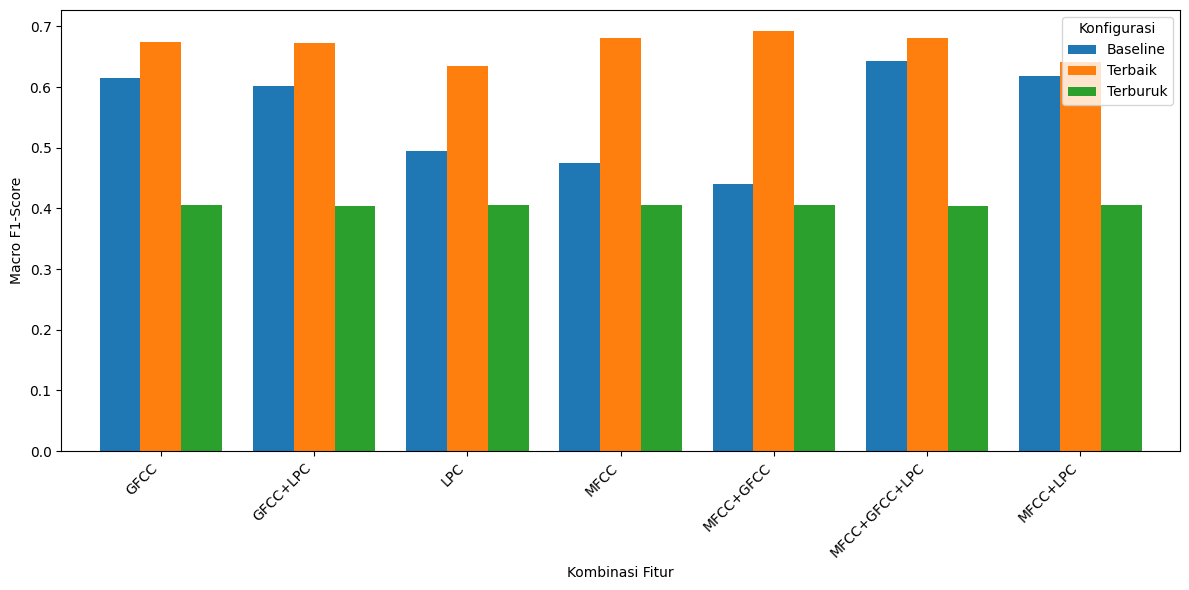

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Load hasil tuning
df = pd.read_csv(
    r"C:\Personal\coding\S1\hadi_skripsi\Results\Tuning\cnn_results.csv"
)

# =====================================
# BASELINE
# =====================================

baseline = df[
    (df["k1"] == 32) &
    (df["k2"] == 64) &
    (df["dropout1"] == 0.2) &
    (df["dropout2"] == 0.3) &
    (df["batch_size"] == 32) &
    (df["lr"] == 0.001)
].copy()

baseline["jenis"] = "Baseline"

# =====================================
# TERBAIK
# =====================================

best = df.loc[
    df.groupby("feature")["f1_score"].idxmax()
].copy()

best["jenis"] = "Terbaik"

# =====================================
# TERBURUK
# =====================================

worst = df.loc[
    df.groupby("feature")["f1_score"].idxmin()
].copy()

worst["jenis"] = "Terburuk"

# =====================================
# GABUNGKAN
# =====================================

result = pd.concat([
    baseline,
    best,
    worst
])

# =====================================
# PIVOT UNTUK GRAFIK
# =====================================

pivot = result.pivot(
    index="feature",
    columns="jenis",
    values="f1_score"
)

# Urutan kolom
pivot = pivot[
    ["Baseline", "Terbaik", "Terburuk"]
]

# =====================================
# PLOT
# =====================================

ax = pivot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.ylabel("Macro F1-Score")
plt.xlabel("Kombinasi Fitur")
# plt.title("Perbandingan Konfigurasi Baseline, Terbaik, dan Terburuk")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Konfigurasi")

plt.tight_layout()
plt.show()

In [2]:
best = df.loc[df.groupby("feature")["f1_score"].idxmax()]

cols = [
    "feature",
    "k1",
    "k2",
    "batch_size",
    "lr",
    "dropout1",
    "dropout2",
    "f1_score"
]

print(best[cols])

            feature  k1   k2  batch_size     lr  dropout1  dropout2  f1_score
523            GFCC  64  256          16  0.001       0.3       0.3  0.674348
1828       GFCC+LPC  64  256          16  0.001       0.3       0.4  0.673279
811             LPC  64  128          16  0.001       0.3       0.3  0.635450
46             MFCC  32  128          16  0.001       0.2       0.4  0.680503
1048      MFCC+GFCC  32  256          32  0.001       0.2       0.3  0.692534
2044  MFCC+GFCC+LPC  32  256          16  0.001       0.3       0.4  0.681696
1480       MFCC+LPC  64  256          32  0.001       0.2       0.3  0.641250


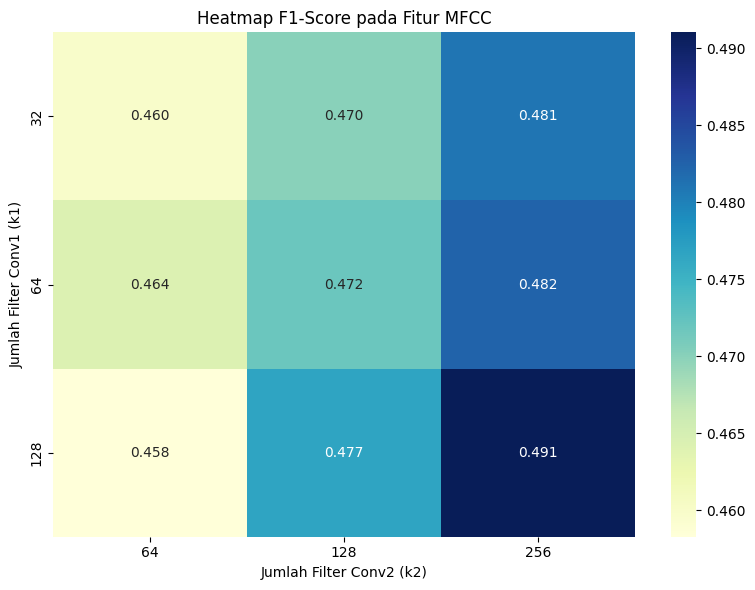

In [3]:
import seaborn as sns

mfcc = df[df["feature"] == "MFCC"]

heatmap_data = (
    mfcc.groupby(["k1","k2"])["f1_score"]
    .mean()
    .reset_index()
    .pivot(index="k1", columns="k2", values="f1_score")
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Heatmap F1-Score pada Fitur MFCC")
plt.xlabel("Jumlah Filter Conv2 (k2)")
plt.ylabel("Jumlah Filter Conv1 (k1)")

plt.tight_layout()
plt.show()

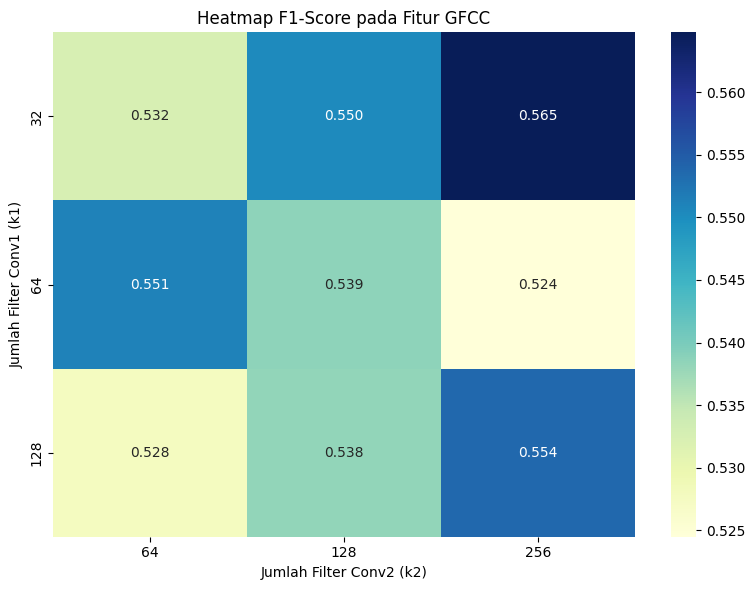

In [4]:
import seaborn as sns

gfcc = df[df["feature"] == "GFCC"]

heatmap_data = (
    gfcc.groupby(["k1","k2"])["f1_score"]
    .mean()
    .reset_index()
    .pivot(index="k1", columns="k2", values="f1_score")
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Heatmap F1-Score pada Fitur GFCC")
plt.xlabel("Jumlah Filter Conv2 (k2)")
plt.ylabel("Jumlah Filter Conv1 (k1)")

plt.tight_layout()
plt.show()

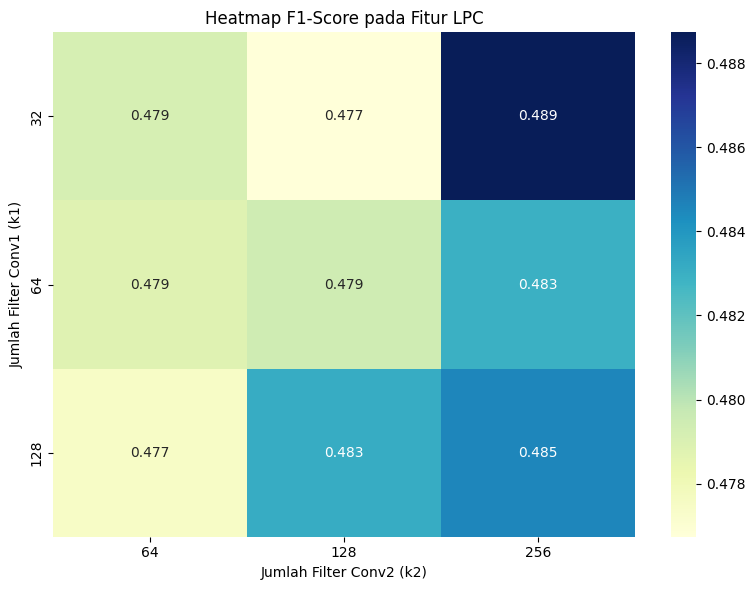

In [5]:
import seaborn as sns

lpc = df[df["feature"] == "LPC"]

heatmap_data = (
    lpc.groupby(["k1","k2"])["f1_score"]
    .mean()
    .reset_index()
    .pivot(index="k1", columns="k2", values="f1_score")
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Heatmap F1-Score pada Fitur LPC")
plt.xlabel("Jumlah Filter Conv2 (k2)")
plt.ylabel("Jumlah Filter Conv1 (k1)")

plt.tight_layout()
plt.show()

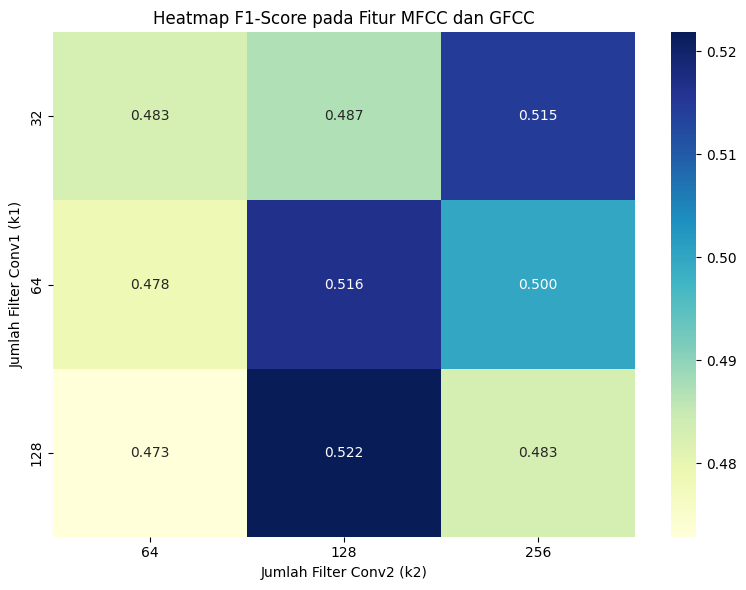

In [6]:
mfcc_gfcc = df[df["feature"] == "MFCC+GFCC"]

heatmap_data = (
    mfcc_gfcc.groupby(["k1","k2"])["f1_score"]
    .mean()
    .reset_index()
    .pivot(index="k1", columns="k2", values="f1_score")
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Heatmap F1-Score pada Fitur MFCC dan GFCC")
plt.xlabel("Jumlah Filter Conv2 (k2)")
plt.ylabel("Jumlah Filter Conv1 (k1)")

plt.tight_layout()
plt.show()

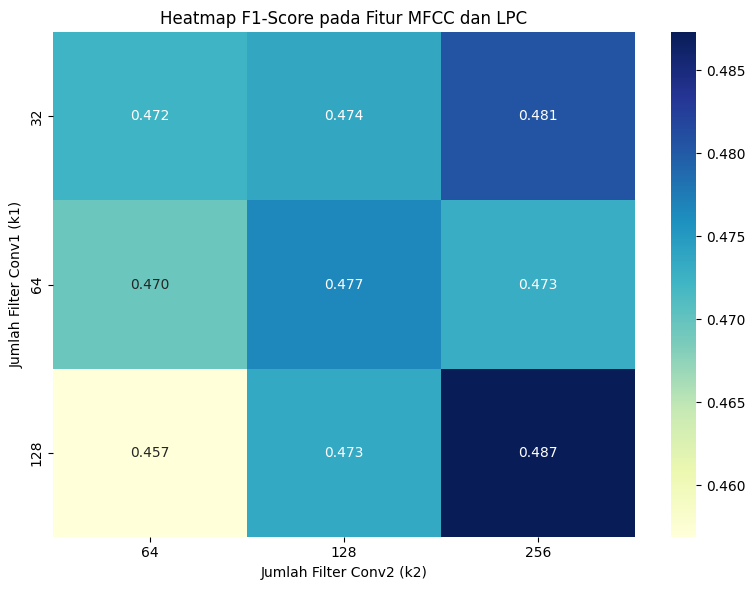

In [7]:
mfcc_lpc = df[df["feature"] == "MFCC+LPC"]

heatmap_data = (
    mfcc_lpc.groupby(["k1","k2"])["f1_score"]
    .mean()
    .reset_index()
    .pivot(index="k1", columns="k2", values="f1_score")
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Heatmap F1-Score pada Fitur MFCC dan LPC")
plt.xlabel("Jumlah Filter Conv2 (k2)")
plt.ylabel("Jumlah Filter Conv1 (k1)")

plt.tight_layout()
plt.show()

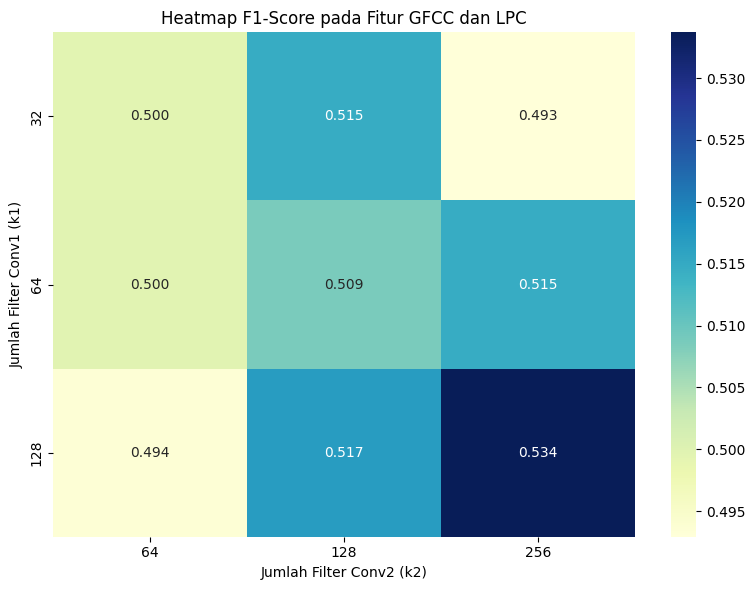

In [8]:
gfcc_lpc = df[df["feature"] == "GFCC+LPC"]

heatmap_data = (
    gfcc_lpc.groupby(["k1","k2"])["f1_score"]
    .mean()
    .reset_index()
    .pivot(index="k1", columns="k2", values="f1_score")
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Heatmap F1-Score pada Fitur GFCC dan LPC")
plt.xlabel("Jumlah Filter Conv2 (k2)")
plt.ylabel("Jumlah Filter Conv1 (k1)")

plt.tight_layout()
plt.show()

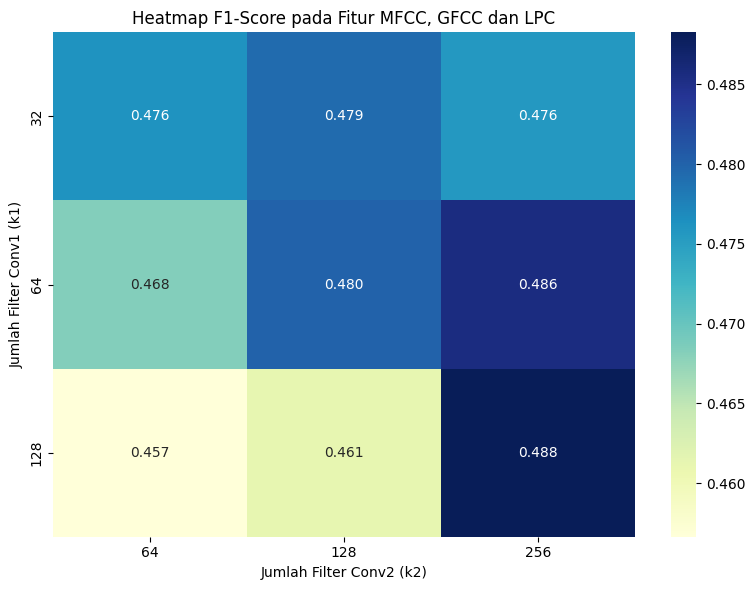

In [9]:
mfcc_gfcc_lpc = df[df["feature"] == "MFCC+GFCC+LPC"]

heatmap_data = (
    mfcc_gfcc_lpc.groupby(["k1","k2"])["f1_score"]
    .mean()
    .reset_index()
    .pivot(index="k1", columns="k2", values="f1_score")
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Heatmap F1-Score pada Fitur MFCC, GFCC dan LPC")
plt.xlabel("Jumlah Filter Conv2 (k2)")
plt.ylabel("Jumlah Filter Conv1 (k1)")

plt.tight_layout()
plt.show()

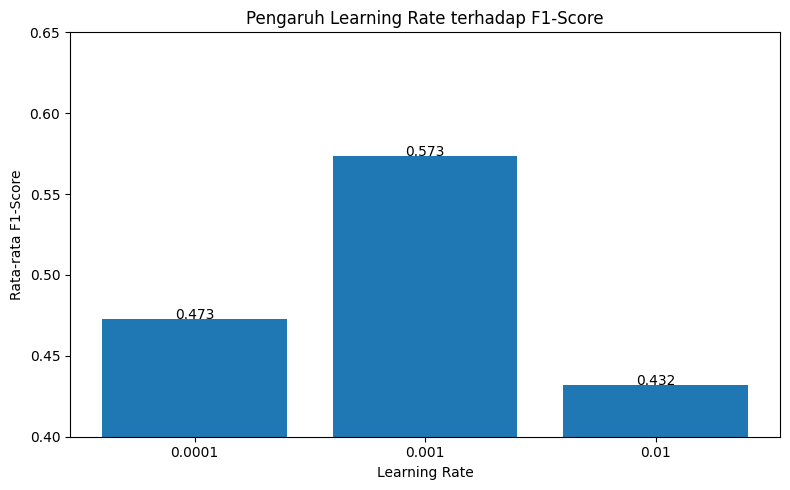

In [18]:
result = df.groupby("lr")["f1_score"].mean().reset_index()

plt.figure(figsize=(8,5))
plt.bar(result["lr"].astype(str), result["f1_score"])
plt.ylim(0.4, 0.65)

plt.xlabel("Learning Rate")
plt.ylabel("Rata-rata F1-Score")
plt.title("Pengaruh Learning Rate terhadap F1-Score")

for i, v in enumerate(result["f1_score"]):
    plt.text(i, v, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

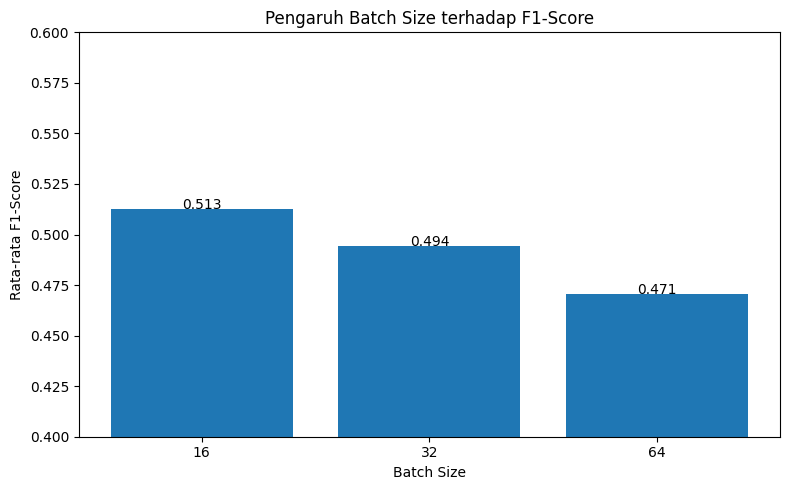

In [19]:


result = df.groupby("batch_size")["f1_score"].mean().reset_index()

plt.figure(figsize=(8,5))
plt.bar(result["batch_size"].astype(str), result["f1_score"])
plt.ylim(0.4, 0.6)

plt.xlabel("Batch Size")
plt.ylabel("Rata-rata F1-Score")
plt.title("Pengaruh Batch Size terhadap F1-Score")

for i, v in enumerate(result["f1_score"]):
    plt.text(i, v, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()

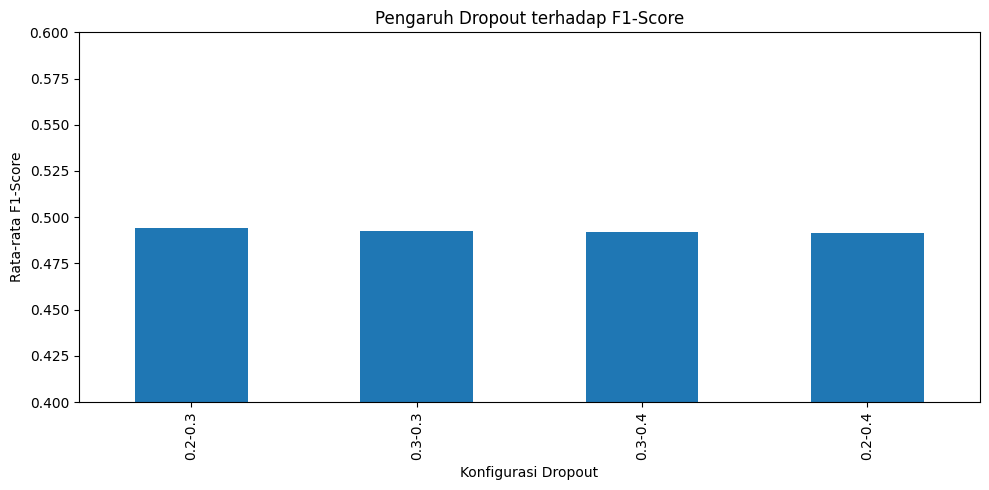

In [22]:
df["dropout_config"] = (
    df["dropout1"].astype(str)
    + "-"
    + df["dropout2"].astype(str)
)

result = (
    df.groupby("dropout_config")["f1_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
result.plot(kind="bar")
plt.ylim(0.4, 0.6)

plt.ylabel("Rata-rata F1-Score")
plt.xlabel("Konfigurasi Dropout")
plt.title("Pengaruh Dropout terhadap F1-Score")

plt.tight_layout()
plt.show()

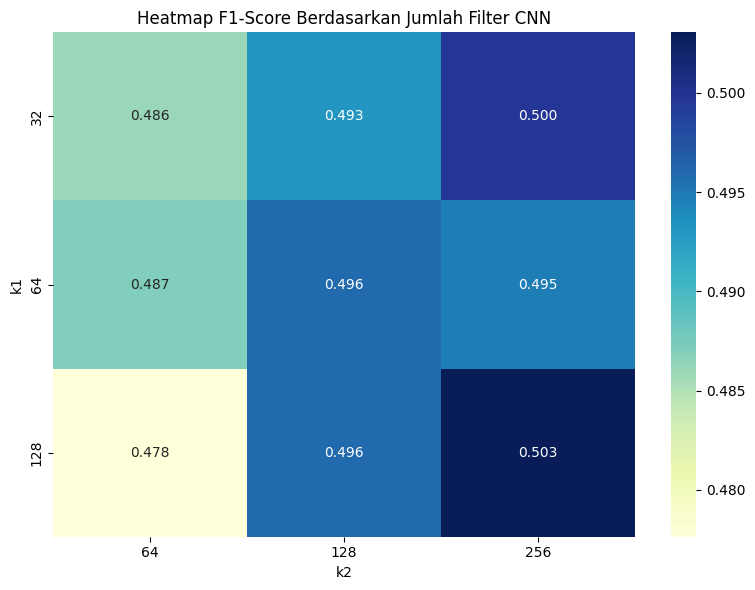

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = (
    df.groupby(["k1","k2"])["f1_score"]
    .mean()
    .reset_index()
    .pivot(index="k1", columns="k2", values="f1_score")
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("Heatmap F1-Score Berdasarkan Jumlah Filter CNN")
plt.xlabel("k2")
plt.ylabel("k1")

plt.tight_layout()
plt.show()

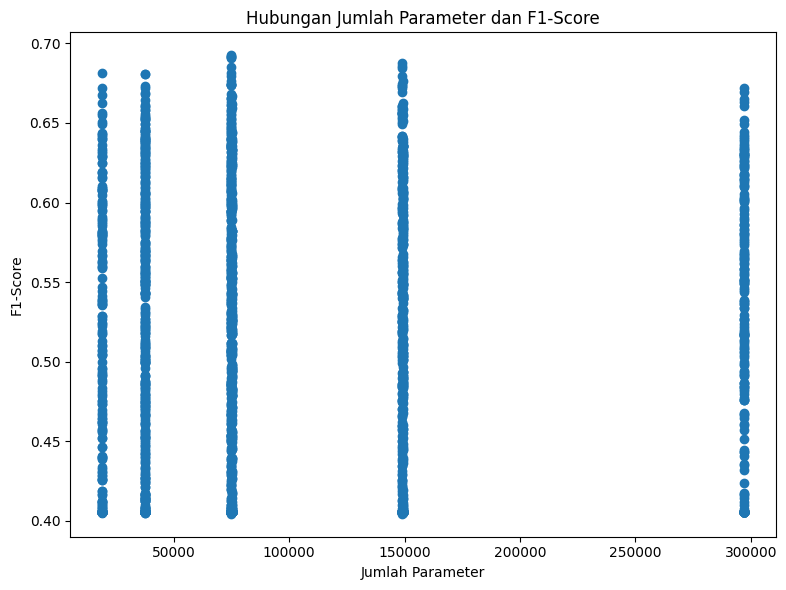

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["num_params"],
    df["f1_score"]
)

plt.xlabel("Jumlah Parameter")
plt.ylabel("F1-Score")
plt.title("Hubungan Jumlah Parameter dan F1-Score")

plt.tight_layout()
plt.show()

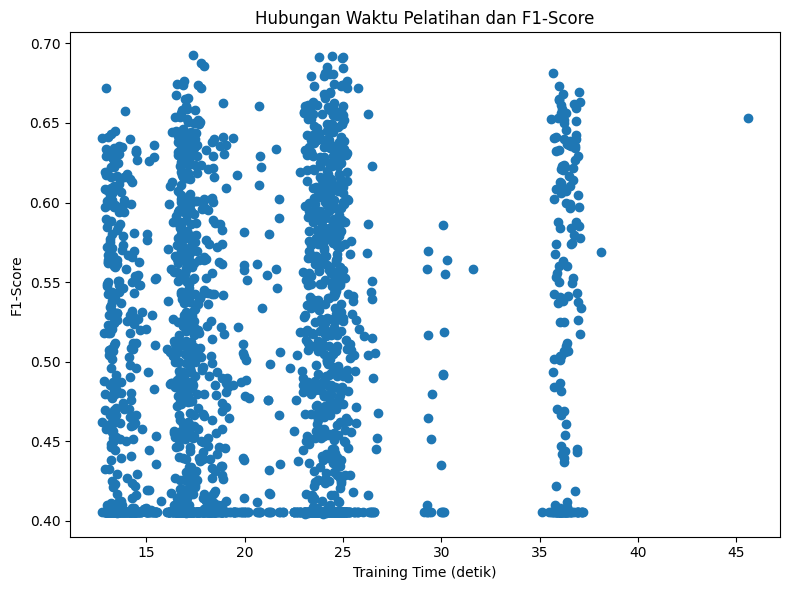

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["training_time_sec"],
    df["f1_score"]
)

plt.xlabel("Training Time (detik)")
plt.ylabel("F1-Score")
plt.title("Hubungan Waktu Pelatihan dan F1-Score")

plt.tight_layout()
plt.show()

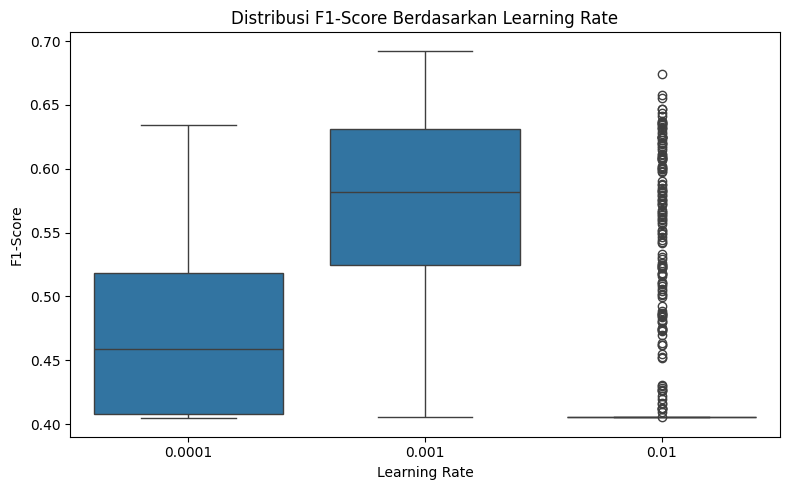

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="lr",
    y="f1_score"
)

plt.xlabel("Learning Rate")
plt.ylabel("F1-Score")
plt.title("Distribusi F1-Score Berdasarkan Learning Rate")

plt.tight_layout()
plt.show()

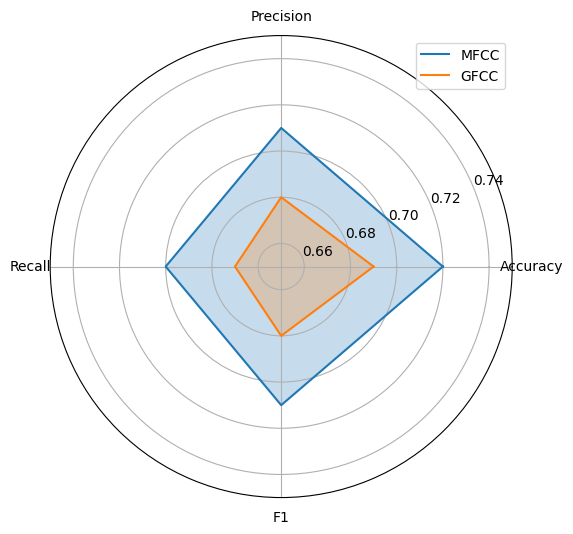

In [17]:
import numpy as np
import matplotlib.pyplot as plt

categories = ['Accuracy', 'Precision', 'Recall', 'F1']
N = len(categories)

mfcc = [0.72, 0.71, 0.70, 0.71]
gfcc = [0.69, 0.68, 0.67, 0.68]

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

mfcc += mfcc[:1]
gfcc += gfcc[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

ax.plot(angles, mfcc, label='MFCC')
ax.fill(angles, mfcc, alpha=0.25)

ax.plot(angles, gfcc, label='GFCC')
ax.fill(angles, gfcc, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0.65, 0.75)

ax.legend()

plt.show()

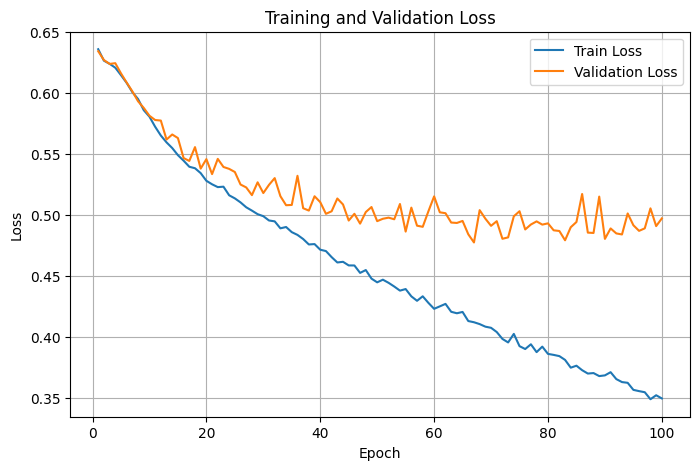

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(
    r"C:\Personal\coding\S1\hadi_skripsi\Results\result csv\MFCC+GFCC+LPC_tuned_learning_curve.csv"
)

plt.figure(figsize=(8, 5))

plt.plot(
    df["epoch"],
    df["train_loss"],
    # marker="o",
    label="Train Loss"
)

plt.plot(
    df["epoch"],
    df["val_loss"],
    # marker="s",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)


plt.show()

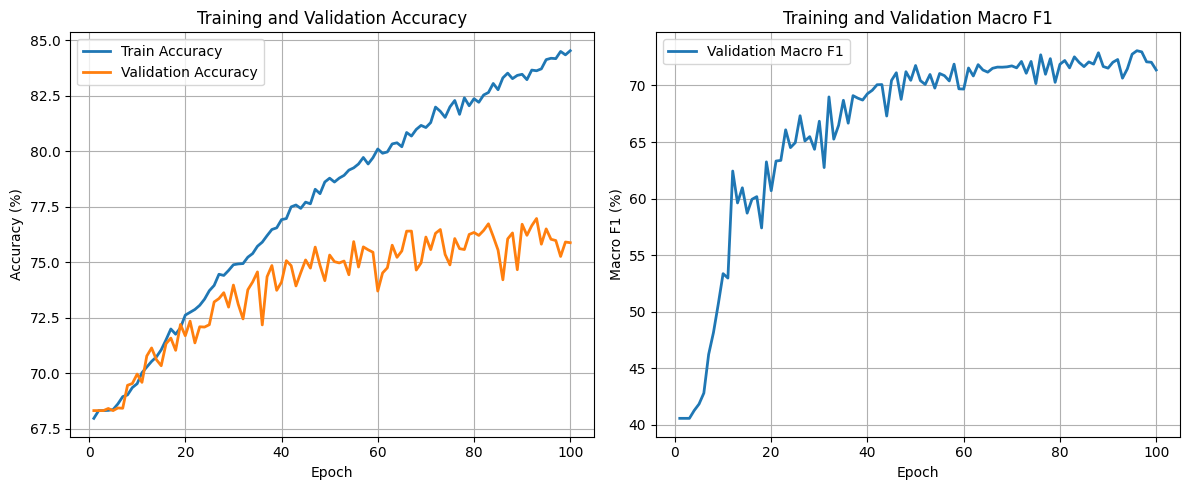

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
# df = pd.read_csv(
#     r"C:\Personal\coding\S1\hadi_skripsi\Results\Final_KFold\GFCC_baseline_learning_curve.csv"
# )

# Ubah F1 menjadi persen
df["val_f1"] = df["val_f1"] * 100

# ==========================================
# ACCURACY DAN F1 SCORE (SEBELAHAN)
# ==========================================

fig, ax = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# ---------------------------
# Accuracy
# ---------------------------

ax[0].plot(
    df["epoch"],
    df["train_acc"],
    # marker="o",
    linewidth=2,
    label="Train Accuracy"
)

ax[0].plot(
    df["epoch"],
    df["val_acc"],
    # marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

ax[0].set_title("Training and Validation Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy (%)")

ax[0].legend()
ax[0].grid(True)

# ---------------------------
# Macro F1
# ---------------------------

ax[1].plot(
    df["epoch"],
    df["val_f1"],
    # marker="^",
    linewidth=2,
    label="Validation Macro F1"
)

ax[1].set_title("Training and Validation Macro F1")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Macro F1 (%)")

ax[1].legend()
ax[1].grid(True)

# ---------------------------
# Layout
# ---------------------------

plt.tight_layout()

plt.show()

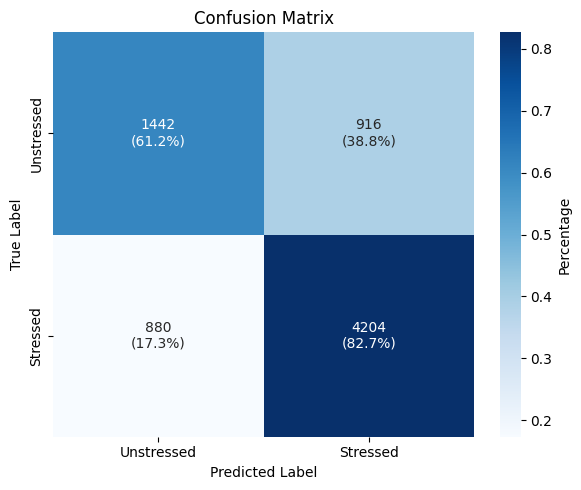

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load confusion matrix
df = pd.read_csv(
    r"C:\Personal\coding\S1\hadi_skripsi\Results\result csv\MFCC+GFCC+LPC_tuned_confusion_matrix.csv",
    index_col=0
)

labels = ["Unstressed", "Stressed"]

# Ubah ke numpy
cm = df.to_numpy()

# Normalisasi per baris (berdasarkan kelas sebenarnya)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Buat anotasi: angka + persentase
annot = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_norm[i, j]:.1%})"

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_norm,
    annot=annot,
    fmt="",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"label": "Percentage"}
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    r"C:\Personal\coding\S1\hadi_skripsi\Results\Tuning\cnn_results.csv"
)

lr_avg = df.groupby("lr")["f1_score"].mean().reset_index()

plt.figure(figsize=(6,5))

plt.bar(
    lr_avg["lr"].astype(str),
    lr_avg["f1_score"] * 100
)

plt.xlabel("Learning Rate")
plt.ylabel("Average Macro F1 (%)")
plt.title("Average Macro F1 for Each Learning Rate")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
batch_avg = df.groupby("batch_size")["f1_score"].mean().reset_index()

plt.figure(figsize=(6,5))

plt.bar(
    batch_avg["batch_size"].astype(str),
    batch_avg["f1_score"] * 100
)

plt.xlabel("Batch Size")
plt.ylabel("Average Macro F1 (%)")
plt.title("Average Macro F1 for Each Batch Size")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()